# Indexing visualisation

Visualise how an index selects elements with `index`.

In [1]:
from pprint import pprint

import numpy as np

import rainbow_tensor as rt

For the array `np.arange(8).reshape(2, 2, 2)` the index `(0, slice(None), 1)` selects the values 1 and 3.

array([[[0, 1],
        [2, 3]],

       [[4, 5],
        [6, 7]]])
array([1, 3])


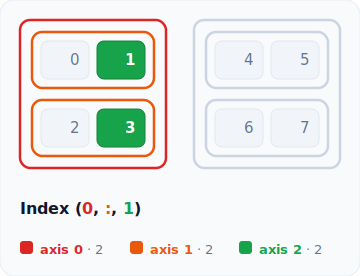

Original shape: (2, 2, 2)
Index: 0, :, 1
Result shape: (2,)
Axis 0 is removed because integer index 0 is used.
Axis 1 is kept because slice : is used.
Axis 2 is removed because integer index 1 is used.


In [2]:
x = np.arange(8).reshape(2, 2, 2)
idx = (0, slice(None), 1)
pprint(x)
pprint(x[idx])
rt.index(x, idx)

Slices keep an axis. Here axis 1 is kept and the result shape is `(2, 2)`.

array([[[0, 1],
        [2, 3]],

       [[4, 5],
        [6, 7]]])
array([[2, 3],
       [6, 7]])


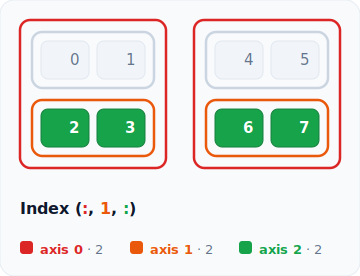

Original shape: (2, 2, 2)
Index: :, 1, :
Result shape: (2, 2)
Axis 0 is kept because slice : is used.
Axis 1 is removed because integer index 1 is used.
Axis 2 is kept because slice : is used.


In [3]:
x = np.arange(8).reshape(2, 2, 2)
idx = (slice(None), 1, slice(None))
pprint(x)
pprint(x[idx])
rt.index(x, idx)

## Dark theme

An index view reads just as clearly in the dark theme. The selected path keeps its colour while the rest of the tensor is dimmed.

array([1, 3])


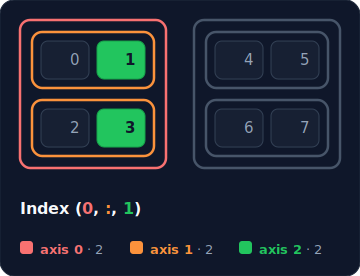

Original shape: (2, 2, 2)
Index: 0, :, 1
Result shape: (2,)
Axis 0 is removed because integer index 0 is used.
Axis 1 is kept because slice : is used.
Axis 2 is removed because integer index 1 is used.


In [4]:
x = np.arange(8).reshape(2, 2, 2)
idx = (0, slice(None), 1)
pprint(x[idx])
rt.index(x, idx, theme="dark")

## Float values and precision

Real float arrays format to a chosen precision, and the selected values stay aligned with the rest of the column.

array([[0.        , 0.09090909, 0.18181818, 0.27272727],
       [0.36363636, 0.45454545, 0.54545455, 0.63636364],
       [0.72727273, 0.81818182, 0.90909091, 1.        ]])
array([0.36363636, 0.45454545, 0.54545455, 0.63636364])


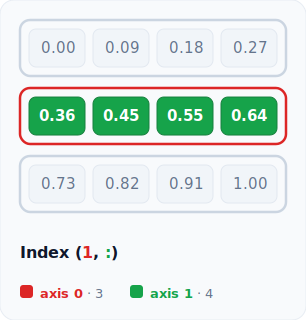

Original shape: (3, 4)
Index: 1, :
Result shape: (4,)
Axis 0 is removed because integer index 1 is used.
Axis 1 is kept because slice : is used.


In [5]:
x = np.linspace(0, 1, 12).reshape(3, 4)
idx = (1, slice(None))
pprint(x)
pprint(x[idx])
rt.index(x, idx, precision=2)

## Negative indices

Negative integers count from the end. Here `-1` is the last block, the same as `1`.

array([[[0, 1],
        [2, 3]],

       [[4, 5],
        [6, 7]]])
array([5, 7])


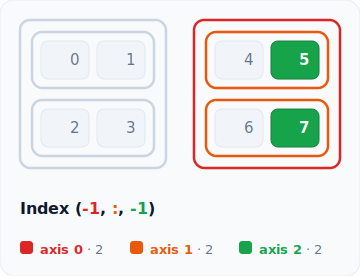

Original shape: (2, 2, 2)
Index: -1, :, -1
Result shape: (2,)
Axis 0 is removed because integer index 1 is used.
Axis 1 is kept because slice : is used.
Axis 2 is removed because integer index 1 is used.


In [6]:
x = np.arange(8).reshape(2, 2, 2)
idx = (-1, slice(None), -1)
pprint(x)
pprint(x[idx])
rt.index(x, idx)

## Reversed and stepped slices

Slice bounds and steps may be negative. `::-1` reverses an axis and `4:1:-1` walks it backwards.

array([0, 1, 2, 3, 4])
array([4, 3, 2])


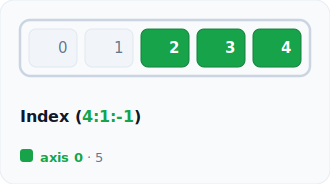

Original shape: (5,)
Index: 4:1:-1
Result shape: (3,)
Axis 0 is kept because slice 4:1:-1 is used.


In [7]:
x = np.arange(5)
idx = (slice(4, 1, -1),)
pprint(x)
pprint(x[idx])
rt.index(x, idx)

## Ellipsis

`...` fills the axes you leave out, so `(0, ..., 1)` keeps the middle axis without naming it.

array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5]],

       [[ 6,  7],
        [ 8,  9],
        [10, 11]]])
array([1, 3, 5])


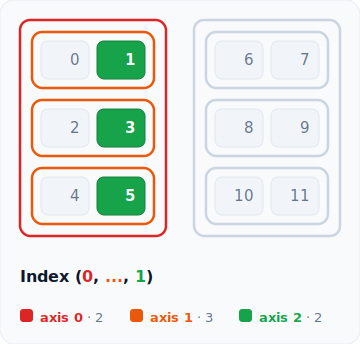

Original shape: (2, 3, 2)
Index: 0, ..., 1
Result shape: (3,)
Axis 0 is removed because integer index 0 is used.
Axis 1 is kept because slice : is used.
Axis 2 is removed because integer index 1 is used.


In [8]:
x = np.arange(12).reshape(2, 3, 2)
idx = (0, ..., 1)
pprint(x)
pprint(x[idx])
rt.index(x, idx)

## New axis with None

`None` inserts a size 1 axis. The selection is unchanged but the result shape gains a `1`, named in the explanation.

array([[0, 1, 2],
       [3, 4, 5]])
array([[3, 4, 5]])
(1, 3)


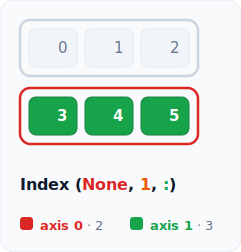

Original shape: (2, 3)
Index: None, 1, :
Result shape: (1, 3)
A new size 1 axis is inserted by None at result position 0.
Axis 0 is removed because integer index 1 is used.
Axis 1 is kept because slice : is used.


In [9]:
x = np.arange(6).reshape(2, 3)
idx = (None, 1, slice(None))
pprint(x)
pprint(x[idx])
pprint(x[idx].shape)
rt.index(x, idx)

## Clear error messages

An out of range index points at the offending axis instead of failing silently.

In [10]:
x = np.arange(8).reshape(2, 2, 2)
pprint(x)
try:
    rt.index(x, (2, slice(None), 1))
except IndexError as e:
    print(e)

array([[[0, 1],
        [2, 3]],

       [[4, 5],
        [6, 7]]])
axis 0: index 2 is out of range for size 2


## Higher dimensions

Indexing works at any rank. Here a 4D tensor keeps axes 1 and 3 and the result shape is `(2, 2)`.

array([[[[ 0,  1],
         [ 2,  3]],

        [[ 4,  5],
         [ 6,  7]]],


       [[[ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15]]]])
array([[ 8,  9],
       [12, 13]])


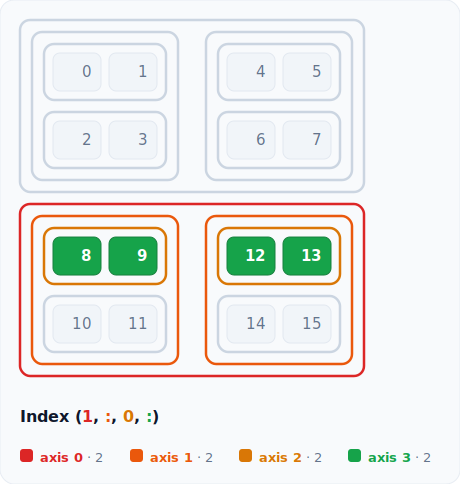

Original shape: (2, 2, 2, 2)
Index: 1, :, 0, :
Result shape: (2, 2)
Axis 0 is removed because integer index 1 is used.
Axis 1 is kept because slice : is used.
Axis 2 is removed because integer index 0 is used.
Axis 3 is kept because slice : is used.


In [11]:
x = np.arange(16).reshape(2, 2, 2, 2)
idx = (1, slice(None), 0, slice(None))
pprint(x)
pprint(x[idx])
rt.index(x, idx)

## Boolean masks

A boolean mask of matching shape highlights every True position. The result is 1D with one entry per selected element.

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])
array([[ True, False, False,  True, False],
       [False,  True, False, False,  True],
       [False, False,  True, False, False],
       [ True, False, False,  True, False]])
array([ 0,  3,  6,  9, 12, 15, 18])


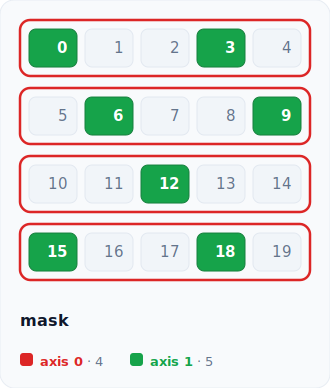

Original shape: (4, 5)
Advanced indexing with a boolean mask.
The mask keeps 7 elements where it is True.
Result shape: (7,)


In [12]:
x = np.arange(20).reshape(4, 5)
mask = x % 3 == 0
pprint(x)
pprint(mask)
pprint(x[mask])
rt.index(x, mask)

## Fancy indexing with integer arrays

Integer arrays gather coordinates. Paired arrays pick the points `(0, 1)`, `(2, 4)`, and `(3, 0)`, so the result shape is `(3,)`.

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])
array([ 1, 14, 15])


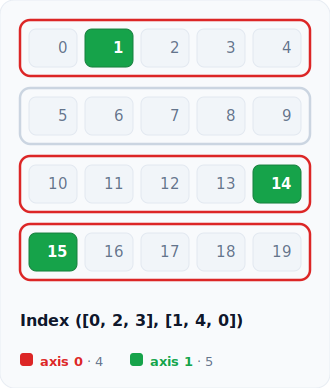

Original shape: (4, 5)
Index: [0, 2, 3], [1, 4, 0]
Advanced indexing with integer arrays.
Axes 0, 1 gather 3 positions together.
Result shape: (3,)


In [13]:
x = np.arange(20).reshape(4, 5)
idx = ([0, 2, 3], [1, 4, 0])
pprint(x)
pprint(x[idx])
rt.index(x, idx)

Integer arrays combine with slices too. Here axis 0 gathers rows 0 and 3 while axis 1 keeps the slice `1:4`, giving result shape `(2, 3)`.

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])
array([[ 1,  2,  3],
       [16, 17, 18]])


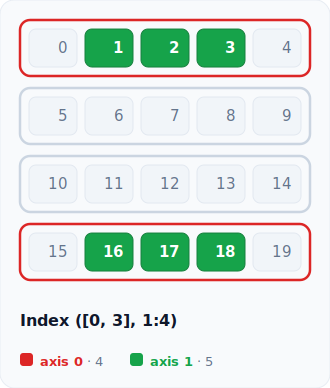

Original shape: (4, 5)
Index: [0, 3], 1:4
Advanced indexing with integer arrays.
Axes 0 gather 2 positions together.
Result shape: (2, 3)


In [14]:
x = np.arange(20).reshape(4, 5)
idx = ([0, 3], slice(1, 4))
pprint(x)
pprint(x[idx])
rt.index(x, idx)

## Advanced indices split by a slice

When a slice separates the integer arrays, NumPy moves the gathered axis to the front of the result. Here axes 0 and 2 are gathered and axis 1 keeps its slice, so the result shape is `(2, 4)`.

array([[ 1,  6, 11, 16],
       [43, 48, 53, 58]])


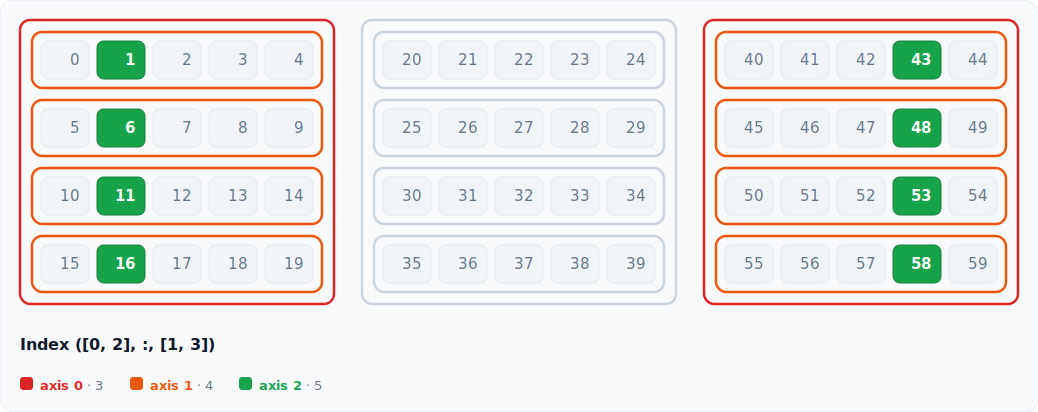

Original shape: (3, 4, 5)
Index: [0, 2], :, [1, 3]
Advanced indexing with integer arrays.
Axes 0, 2 gather 2 positions together.
A slice separates the gathered axes, so the gathered axis moves to the front.
Result shape: (2, 4)


In [15]:
x = np.arange(60).reshape(3, 4, 5)
idx = ([0, 2], slice(None), [1, 3])
pprint(x[idx])
rt.index(x, idx)